<a href="https://colab.research.google.com/github/sebamyu/SME-Retail-Smart-Bundle/blob/main/Retail_Cross_Sell_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<b><font color="#000080" size="6">Data Science / AI Solution Proposal</font></b>

# Smart Bundle & Cross-Sell

**Business Domain:** Retail Industry

อรพินธ์ นาคุณ

---

<b><font color="#A9A9A9" size="5">Project Overview</font></b>

**1. Business Problem (ปัญหาที่พบ)**
ในธุรกิจค้าปลีก (Retail) ปัญหาหลักที่ทำให้ร้านค้าสูญเสียโอกาสในการเพิ่มรายได้คือ ลูกค้ามักจะมีขนาดตะกร้าสินค้าที่เล็ก (Basket Size) หรือซื้อสินค้าเพียงชิ้นเดียวต่อบิล การอาศัยดุลยพินิจของพนักงานหน้าร้านในการเชียร์ขายสินค้า (Rule-based / Manual process) มักจะเกิดความลำเอียงและจับคู่ได้เฉพาะสินค้าที่ขายดีอยู่แล้ว ทำให้ไม่สามารถเพิ่มยอดขายได้อย่างเต็มประสิทธิภาพ

**2. Proposed Solution (แนวทางแก้ไข)**
โปรเจกต์นี้จึงขอนำเสนอการสร้าง **"Smart Bundle & Cross-Sell Recommendation Engine"** โดยประยุกต์ใช้เทคนิค **Market Basket Analysis (Apriori Algorithm)** เข้ามาวิเคราะห์ประวัติการซื้อขาย (Sales Transaction) เพื่อค้นหา "กฎความสัมพันธ์แฝง (Association Rules)" ของสินค้าที่มักจะถูกซื้อคู่กัน

**3. Actionable Insight (การนำไปใช้งานจริง)**
ผลลัพธ์จากโมเดลนี้ จะถูกส่งต่อให้ผู้ใช้งานหลัก 2 ส่วนคือ:
* **Marketing Manager:** นำไปจัดโปรโมชั่นแบบแพ็กเกจ (Product Bundling) โดยเจาะจงคู่สินค้าที่มีโอกาสทำกำไรสูง (Margin)
* **Store Manager:** นำไปปรับแผนผังการวางสินค้าหน้าร้าน (Store Layout) ให้นำสินค้าที่เกี่ยวข้องกันมาวางใกล้กัน

**4. Expected Impact & KPI (ผลลัพธ์ที่คาดหวัง)**
* เพิ่มมูลค่าเฉลี่ยต่อคำสั่งซื้อ **(Average Order Value: AOV)** สอดคล้องกับเป้าหมายการ Maximize Revenue
* เพิ่มอัตราส่วนการซื้อสินค้าข้ามหมวดหมู่ **(Cross-sell Ratio)**

**5. Deliverables (สิ่งที่ส่งมอบในโปรเจกต์นี้)**
* **Recommendation Rules:** ตารางกฎความสัมพันธ์เพื่อจัดอันดับคู่สินค้าทำเงิน
* **Mock Dashboard Sketch:** ต้นแบบหน้าจอรายงานผลสำหรับฝ่ายบริหาร เพื่อใช้ประเมินยอดขายที่คาดหวัง (Expected AOV) ก่อนนำผลลัพธ์ไปทดสอบจริงหน้าร้าน (A/B Testing)

---

<b><font color="#A9A9A9" size="5">Data Dictionary</font></b>

ชุดข้อมูลนี้ประกอบด้วยตารางหลัก 2 ตารางที่ใช้ในการวิเคราะห์ Market Basket Analysis

#### 1. ตาราง `Product Master` (ข้อมูลสินค้าอ้างอิง)
ตารางนี้ใช้สำหรับเก็บรายละเอียดของสินค้าแต่ละรายการในร้านค้า

| Column Name | Data Type | Description (คำอธิบาย) | Note / Business Impact |
| :--- | :--- | :--- | :--- |
| `product_id` | String | รหัสสินค้าอ้างอิง | เป็น Key หลักในการเชื่อมข้อมูล (Join) กับตารางยอดขาย |
| `product_name` | String | ชื่อสินค้า | **(⭐ Mock เพิ่มเติม)** เพิ่มเข้ามาเพื่อให้แสดงผลในรายงานอ่านง่าย แทนที่จะแสดงแค่รหัส |
| `product_taxonomies` | String | หมวดหมู่ของสินค้า | ใช้แบ่งกลุ่มสินค้าเพื่อดูพฤติกรรมการซื้อข้ามหมวดหมู่ (Cross-sell) |
| `price` | Float | ราคาขายหน้าร้าน | - |
| `unit_cost` | Float | ต้นทุนสินค้า | **(⭐ Mock เพิ่มเติม)** เพิ่มเพื่อนำไปคำนวณกำไร (Margin) ช่วยให้โมเดลสามารถเลือกแนะนำ "คู่สินค้าที่ให้กำไรสูงสุด" ได้ ตอบโจทย์การ Maximize Revenue |

<br>

#### 2. ตาราง `Sales Transaction` (ข้อมูลประวัติการขาย)
ตารางนี้จำลองประวัติการซื้อสินค้าของลูกค้าแบบรายรายการ (Item-level)

| Column Name | Data Type | Description (คำอธิบาย) | Note / Business Impact |
| :--- | :--- | :--- | :--- |
| `po_id` | String | รหัสใบเสร็จ / Purchase Order | **(สำคัญมาก)** ใช้เป็นตัวจัดกลุ่ม (Group by) ว่าสินค้าใดบ้างที่ถูกซื้อใน "ตะกร้าเดียวกัน" เพื่อนำไปรัน Apriori Algorithm |
| `datetime` | Datetime | วันและเวลาที่มีการซื้อขาย | - |
| `product_id` | String | รหัสสินค้าที่ถูกขาย | ใช้ Join กับตาราง Product Master |
| `price` | Float | ราคาขาย ณ เวลาที่เกิด Transaction | - |
| `qty` | Integer | จำนวนชิ้นที่ซื้อในรายการนั้น | - |
| `customer_id` | String | รหัสลูกค้าระบบสมาชิก | อาจมีค่าว่าง (Null) ได้ หากลูกค้าไม่เป็นสมาชิก (Assumption ของข้อมูลนี้) |
| `promotion_id` | String | รหัสโปรโมชั่นที่ใช้ | ถูกเซ็ตค่าเริ่มต้นเป็น NaN ไว้ก่อน เพราะเป้าหมายของเราคือการ "สร้างโปรโมชั่นใหม่" |
| `store_id` | String | รหัสสาขาที่เกิดการซื้อขาย | ใช้กรองข้อมูลหากต้องการทำ A/B Testing แยกตามสาขาในอนาคต |

<b><font color="#8B0000" size="5">Workflow Diagram</font></b>

(แผนภาพกระบวนการทำงาน)

=== Smart Bundle & Cross-Sell Workflow Diagram ===


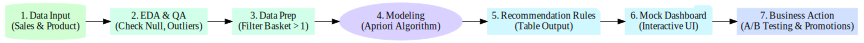

In [1]:
import graphviz
from IPython.display import display

# สร้างแผนภาพ (Diagram)
dot = graphviz.Digraph(comment='Smart Bundle Workflow')
dot.attr(rankdir='LR', size='12,5')

# Nodes
dot.node('A', '1. Data Input\n(Sales & Product)', shape='cylinder', color='#D1FFD3', style='filled')
dot.node('B', '2. EDA & QA\n(Check Null, Outliers)', shape='box', color='#D1FFEA', style='filled')
dot.node('C', '3. Data Prep\n(Filter Basket > 1)', shape='box', color='#D1FFEA', style='filled')
dot.node('D', '4. Modeling\n(Apriori Algorithm)', shape='ellipse', color='#D9D1FF', style='filled')
dot.node('E', '5. Recommendation Rules\n(Table Output)', shape='note', color='#D1F7FF', style='filled')
dot.node('F', '6. Mock Dashboard\n(Interactive UI)', shape='folder', color='#D1F7FF', style='filled') # เพิ่มกล่อง Dashboard
dot.node('G', '7. Business Action\n(A/B Testing & Promotions)', shape='polygon', sides='4', color='#D1E0FF', style='filled')

# Edges
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

print("=== Smart Bundle & Cross-Sell Workflow Diagram ===")
display(dot)

In [2]:
# Import Library

!pip install mlxtend

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<b><font color="#8B0000" size="5">Mock Data (Product Master)</font></b>

(ข้อมูลสินค้า)

In [5]:
# จำลองข้อมูลสินค้า 10 รายการ
# และเพิ่ม column 'unit_cost' เพื่อดูต้นทุนและกำไร

products_data = {
    'product_id': ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10'],
    'product_name': ['แชมพู A', 'ครีมนวดผม A', 'สบู่เหลว B', 'ยาสีฟัน C', 'แปรงสีฟัน C',
                     'กาแฟ D', 'นมสด E', 'น้ำตาล F', 'ขนมปัง G', 'แยม H'],
    'product_taxonomies': ['Personal Care', 'Personal Care', 'Personal Care', 'Personal Care', 'Personal Care',
                           'Beverage', 'Beverage', 'Grocery', 'Bakery', 'Bakery'],
    'price': [120, 120, 89, 55, 45, 150, 45, 25, 40, 65],
    'unit_cost': [80, 85, 50, 30, 20, 90, 35, 15, 25, 40] # เพิ่มคอลัมน์นี้เพื่อนำไปทำกำไร
}
df_product = pd.DataFrame(products_data)

# แสดงผลลัพธ์ตารางข้อมูลสินค้า
print(" === ตารางข้อมูล Product Master (สินค้าอ้างอิง) ===")
display(df_product)

 === ตารางข้อมูล Product Master (สินค้าอ้างอิง) ===


,product_id,product_name,product_taxonomies,price,unit_cost
0,P01,แชมพู A,Personal Care,120,80
1,P02,ครีมนวดผม A,Personal Care,120,85
2,P03,สบู่เหลว B,Personal Care,89,50
3,P04,ยาสีฟัน C,Personal Care,55,30
4,P05,แปรงสีฟัน C,Personal Care,45,20
5,P06,กาแฟ D,Beverage,150,90
6,P07,นมสด E,Beverage,45,35
7,P08,น้ำตาล F,Grocery,25,15
8,P09,ขนมปัง G,Bakery,40,25
9,P10,แยม H,Bakery,65,40


<b><font color="#8B0000" size="5">Mock Data (Sales Transaction)</font></b>

(ประวัติการซื้อ)

In [6]:
# จำลองข้อมูล PO จำนวน 500 บิล
transactions = []
start_date = datetime(2026, 6, 2)

for po_num in range(1, 501):
    po_id = f"PO_{po_num:04d}"
    dt = start_date + timedelta(days=random.randint(0, 30), hours=random.randint(8, 20))
    customer_id = f"C_{random.randint(1, 100):03d}"

    # Pattern Injection (กำหนดความน่าจะเป็นในการซื้อสินค้าคู่กัน)
    basket = []

    # Pattern 1 แชมพู มักซื้อคู่กับ ครีมนวดผม
    if random.random() < 0.3:
        basket.append('P01')
        if random.random() < 0.8: basket.append('P02')

    # Pattern 2 กาแฟ มักซื้อคู่กับ นมสด
    if random.random() < 0.4:
        basket.append('P06')
        if random.random() < 0.7: basket.append('P07')

    # Pattern 3 ขนมปัง มักซื้อคู่กับ แยม
    if random.random() < 0.25:
        basket.append('P09')
        if random.random() < 0.6: basket.append('P10')

    # สุ่มสินค้าอื่น ๆ
    for _ in range(random.randint(0, 2)):
        random_item = random.choice(products_data['product_id'])
        if random_item not in basket:
            basket.append(random_item)

    # สร้าง Transaction rows
    for item in basket:
        idx = products_data['product_id'].index(item)
        transactions.append({
            'datetime': dt,
            'product_id': item,
            'price': products_data['price'][idx],
            'qty': random.randint(1, 2),
            'customer_id': customer_id,
            'promotion_id': np.nan,
            'store_id': f"S_{random.randint(1, 3):02d}",
            'po_id': po_id
        })

df_sales = pd.DataFrame(transactions)

# แสดงผลลัพธ์ตารางข้อมูลประวัติการซื้อ
print("=== ตารางข้อมูล Sales Transaction (ประวัติการซื้อ 500 บิล) ===")
display(df_sales.head())

=== ตารางข้อมูล Sales Transaction (ประวัติการซื้อ 500 บิล) ===


,datetime,product_id,price,qty,customer_id,promotion_id,store_id,po_id
0,2026-06-03 19:00:00,P01,120,1,C_010,NaN,S_02,PO_0001
1,2026-06-03 19:00:00,P02,120,2,C_010,NaN,S_02,PO_0001
2,2026-06-03 19:00:00,P06,150,1,C_010,NaN,S_01,PO_0001
3,2026-06-03 19:00:00,P07,45,1,C_010,NaN,S_01,PO_0001
4,2026-06-03 19:00:00,P09,40,1,C_010,NaN,S_03,PO_0001


<b><font color="#8B0000" size="5">Data Preparation & Simple EDA</font></b>

In [7]:
# Join ข้อมูล Sales กับ Product
df_merged = pd.merge(df_sales, df_product, on=['product_id', 'price'], how='left')

# กรองเฉพาะบิลที่มีสินค้ามากกว่า 1 ชิ้น (Basket Size > 1) สำหรับ Market Basket Analysis
basket_sizes = df_merged.groupby('po_id').size()
valid_po = basket_sizes[basket_sizes > 1].index
df_mba = df_merged[df_merged['po_id'].isin(valid_po)]

print("=== สรุปการเตรียมข้อมูล (Data Preparation) ===")
print(f"- จำนวนบิลทั้งหมด (Total POs): {len(basket_sizes)} บิล")
print(f"- จำนวนบิลที่มีสินค้า > 1 ชิ้น (นำไปวิเคราะห์ต่อ): {len(valid_po)} บิล")
print(f"- จำนวนบิลที่ถูกตัดออก (เนื่องจากซื้อแค่ชิ้นเดียว): {len(basket_sizes) - len(valid_po)} บิล\n")

print("=== ตัวอย่างข้อมูลที่พร้อมนำไปเข้าโมเดล (df_mba) ===")
display(df_mba.head())

=== สรุปการเตรียมข้อมูล (Data Preparation) ===
จำนวนบิลทั้งหมด (Total POs): 457 บิล
จำนวนบิลที่มีสินค้า > 1 ชิ้น (นำไปวิเคราะห์ต่อ): 366 บิล
จำนวนบิลที่ถูกตัดออก (เนื่องจากซื้อแค่ชิ้นเดียว): 91 บิล

=== ตัวอย่างข้อมูลที่พร้อมนำไปเข้าโมเดล (df_mba) ===


,datetime,product_id,price,qty,customer_id,promotion_id,store_id,po_id,product_name,product_taxonomies,unit_cost
0,2026-06-03 19:00:00,P01,120,1,C_010,NaN,S_02,PO_0001,แชมพู A,Personal Care,80
1,2026-06-03 19:00:00,P02,120,2,C_010,NaN,S_02,PO_0001,ครีมนวดผม A,Personal Care,85
2,2026-06-03 19:00:00,P06,150,1,C_010,NaN,S_01,PO_0001,กาแฟ D,Beverage,90
3,2026-06-03 19:00:00,P07,45,1,C_010,NaN,S_01,PO_0001,นมสด E,Beverage,35
4,2026-06-03 19:00:00,P09,40,1,C_010,NaN,S_03,PO_0001,ขนมปัง G,Bakery,25


<b><font color="#8B0000" size="5">Data Quality Check</font></b>

(การตรวจสอบคุณภาพข้อมูล)

In [8]:
print("1. Data Quality Check")

# เช็คค่าว่าง (Missing Values)
print("สรุปจำนวนค่าว่าง (Null) ในแต่ละคอลัมน์ของข้อมูล Sales:")
display(df_sales.isnull().sum())
print("\n*Note: คอลัมน์ promotion_id มีค่าว่าง ซึ่งเป็นเรื่องปกติเพราะไม่ใช่ทุกรายการจะใช้โปรโมชั่น*\n")

# เช็คค่าผิดปกติ (Outliers / Negative Values)
print("ตรวจสอบค่าสถิติ (ราคาและจำนวนสินค้าห้ามติดลบ):")
display(df_sales[['price', 'qty']].describe())

1. Data Quality Check
สรุปจำนวนค่าว่าง (Null) ในแต่ละคอลัมน์ของข้อมูล Sales:


,0
datetime,0
product_id,0
price,0
qty,0
customer_id,0
promotion_id,1258
store_id,0
po_id,0



*Note: คอลัมน์ promotion_id มีค่าว่าง ซึ่งเป็นเรื่องปกติเพราะไม่ใช่ทุกรายการจะใช้โปรโมชั่น*

ตรวจสอบค่าสถิติ (ราคาและจำนวนสินค้าห้ามติดลบ):


,price,qty
count,1258.000000,1258.000000
mean,88.098569,1.480922
std,43.834085,0.499835
min,25.000000,1.000000
25%,45.000000,1.000000
50%,89.000000,1.000000
75%,120.000000,2.000000
max,150.000000,2.000000


<b><font color="#8B0000" size="5">Simple EDA</font></b>

(การสำรวจข้อมูลเบื้องต้น)


2. Exploratory Data Analysis (EDA)


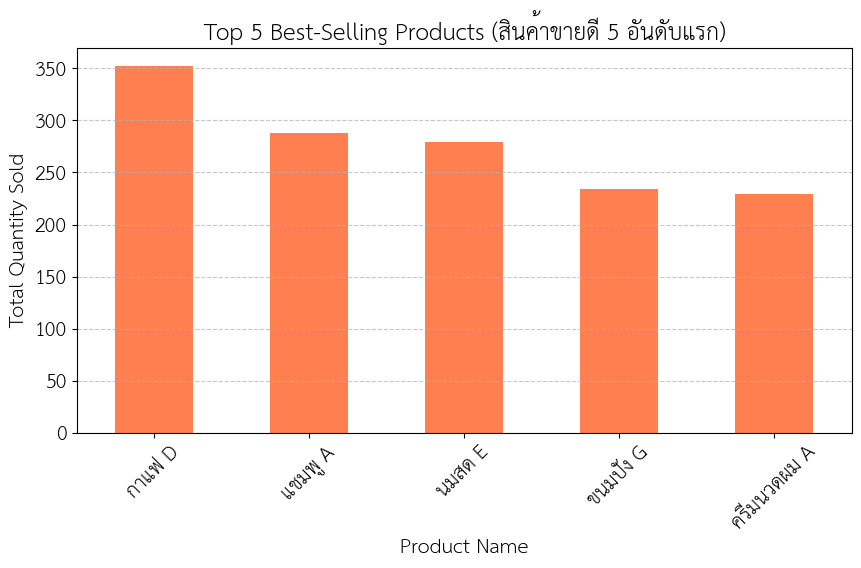

In [9]:
print("\n2. Exploratory Data Analysis (EDA)")

# กราฟ 1 สินค้า 5 อันดับแรกที่ขายดีที่สุด (นับตามจำนวนชิ้น)
top_products = df_merged.groupby('product_name')['qty'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
top_products.plot(kind='bar', color='coral')
plt.title('Top 5 Best-Selling Products (สินค้าขายดี 5 อันดับแรก)', fontsize=16)
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

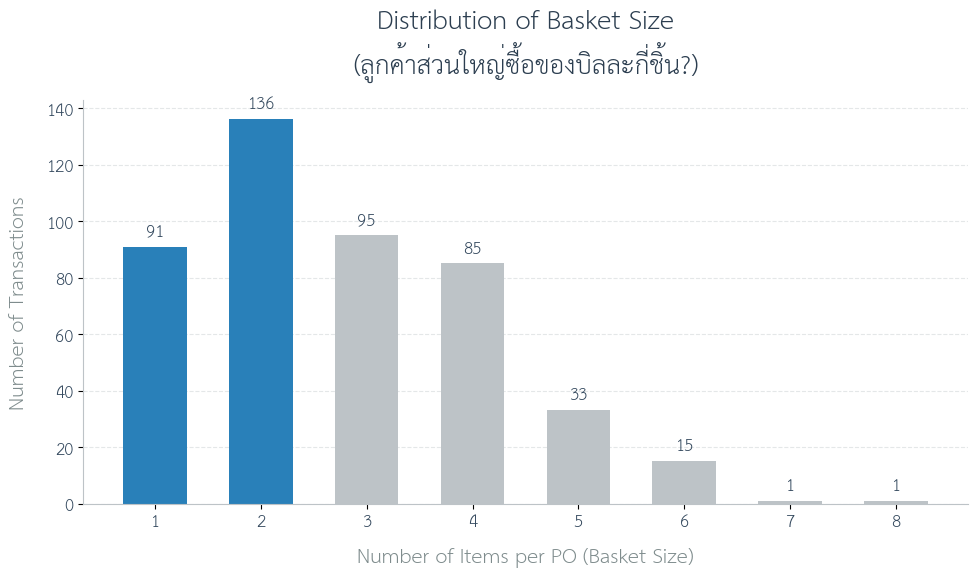


*Business Insight จาก EDA:*
จากกราฟ Distribution of Basket Size จะเห็นว่ามีบิลจำนวนมากที่มีการซื้อสินค้าเพียง 1-2 ชิ้น (แท่งสีน้ำเงิน)
นี่จึงเป็น 'หลักฐานสำคัญ' ที่ยืนยันว่าเราควรนำโมเดล Smart Bundle เข้ามากระตุ้นให้กราฟแท่งเหล่านี้ขยับไปทางขวา (ซื้อ 3-4 ชิ้นขึ้นไป) เพื่อเพิ่ม Average Order Value (AOV)


In [15]:
# กราฟ 2 การกระจายตัวของขนาดตะกร้าสินค้า (Basket Size)

basket_sizes = df_merged.groupby('po_id').size()
data = basket_sizes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2980b9' if x <= 2 else '#bdc3c7' for x in data.index]

bars = ax.bar(data.index, data.values, color=colors, width=0.6, edgecolor='none')

ax.set_title('Distribution of Basket Size\n(ลูกค้าส่วนใหญ่ซื้อของบิลละกี่ชิ้น?)',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_xlabel('Number of Items per PO (Basket Size)', fontsize=14, color='#7f8c8d', labelpad=12)
ax.set_ylabel('Number of Transactions', fontsize=14, color='#7f8c8d', labelpad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

ax.grid(axis='y', linestyle='--', alpha=0.4, color='#bdc3c7')
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, color='#34495e', fontweight='bold')

plt.xticks(data.index, fontsize=12, color='#34495e')
plt.yticks(fontsize=12, color='#34495e')

plt.tight_layout()
plt.show()

# Insight
print("\n*Business Insight จาก EDA:*")
print("จากกราฟ Distribution of Basket Size จะเห็นว่ามีบิลจำนวนมากที่มีการซื้อสินค้าเพียง 1-2 ชิ้น (แท่งสีน้ำเงิน)")
print("นี่จึงเป็น 'หลักฐานสำคัญ' ที่ยืนยันว่าเราควรนำโมเดล Smart Bundle เข้ามากระตุ้นให้กราฟแท่งเหล่านี้ขยับไปทางขวา (ซื้อ 3-4 ชิ้นขึ้นไป) เพื่อเพิ่ม Average Order Value (AOV)")

<b><font color="#8B0000" size="5">Modeling: Pseudo-code & Function</font></b>

ตัวอย่าง (Apriori)

In [11]:
"""
Pseudo-code (โครงร่างลอจิกการทำงานของระบบแนะนำสินค้า)
FUNCTION get_smart_bundle_rules(ข้อมูลตะกร้าสินค้า, ค่าต่ำสุดของSupport, ค่าต่ำสุดของConfidence):
    1. แปลงรูปแบบข้อมูล: จัดกลุ่มสินค้าตามรหัสบิล (po_id) ให้อยู่ในรูป Matrix (One-hot encoding)
       - ถ้าบิลนั้นซื้อสินค้า ให้มีค่าเป็น 1
       - ถ้าไม่ได้ซื้อ ให้มีค่าเป็น 0
    2. หา Frequent Itemsets: รัน Apriori algorithm หาสินค้าที่ถูกซื้อบ่อยเกินกว่า 'ค่าต่ำสุดของSupport'
    3. สร้าง Association Rules: หาความสัมพันธ์ว่าซื้อ A แล้วจะซื้อ B โดยคัดเฉพาะคู่ที่มีความมั่นใจเกิน 'ค่าต่ำสุดของConfidence'
    4. เรียงลำดับความน่าสนใจ: เรียงลำดับกฎจากค่า Lift ที่สูงที่สุดไปหาต่ำสุด (ยิ่ง Lift สูง ยิ่งเกี่ยวข้องกันมาก)
    5. RETURN กฎความสัมพันธ์ที่ได้
"""

# เขียน Function ตัวอย่างของจริงใน Python
def get_smart_bundle_rules(transaction_df, min_support=0.03, min_confidence=0.4):
    """
    ฟังก์ชันตัวอย่างสำหรับหาความสัมพันธ์ของสินค้าเพื่อจัด Bundle
    """
    # 1. จัดรูปแบบข้อมูลเป็น One-hot encoding matrix
    basket_matrix = (transaction_df.groupby(['po_id', 'product_name'])['qty']
                     .sum().unstack().reset_index().fillna(0)
                     .set_index('po_id'))

    # แปลงจำนวนเป็น 1 (ซื้อ) และ 0 (ไม่ซื้อ)
    basket_encoded = basket_matrix.applymap(lambda x: 1 if x > 0 else 0)

    # 2. หาสินค้าที่ถูกซื้อบ่อย (Frequent Itemsets)
    frequent_itemsets = apriori(basket_encoded, min_support=min_support, use_colnames=True)

    # 3. สร้างกฎความสัมพันธ์ (Association Rules)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

    # 4. เรียงลำดับความสำคัญด้วยค่า Lift
    rules = rules.sort_values('lift', ascending=False)

    return rules # 5. คืนค่าผลลัพธ์

<b><font color="#8B0000" size="5">Expected Output: การเรียกใช้งาน Function ตัวอย่าง</font></b>

In [12]:
print("=== ผลลัพธ์กฎการจับคู่สินค้า (Recommendation Rules) ===")

# โยนข้อมูล df_mba (ที่ตัดบิลชิ้นเดียวออกแล้ว) เข้าไปในฟังก์ชัน
recommendation_rules = get_smart_bundle_rules(transaction_df=df_mba, min_support=0.03, min_confidence=0.4)

# โชว์ตารางกฎที่ได้ โดยเลือกมาเฉพาะคอลัมน์สำคัญ 5 คอลัมน์ และดูแค่ 5 อันดับแรก
display(recommendation_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

=== ผลลัพธ์กฎการจับคู่สินค้า (Recommendation Rules) ===


,antecedents,consequents,support,confidence,lift
220,"(กาแฟ D, ครีมนวดผม A, แยม H)","(ขนมปัง G, นมสด E, แชมพู A)",0.030055,0.550000,9.585714
222,"(ขนมปัง G, นมสด E, แชมพู A)","(กาแฟ D, ครีมนวดผม A, แยม H)",0.030055,0.523810,9.585714
223,"(กาแฟ D, ครีมนวดผม A, ขนมปัง G)","(นมสด E, แยม H, แชมพู A)",0.030055,0.440000,8.475789
219,"(นมสด E, แยม H, แชมพู A)","(กาแฟ D, ครีมนวดผม A, ขนมปัง G)",0.030055,0.578947,8.475789
218,"(กาแฟ D, แยม H, แชมพู A)","(นมสด E, ครีมนวดผม A, ขนมปัง G)",0.030055,0.478261,8.335404


<b><font color="#8B0000" size="5">Optional Work: Mock Dashboard Sketch</font></b>

In [23]:
from IPython.display import HTML, display

print("=== 4. Mock Dashboard Sketch (ภาพจำลองหน้าจอสำหรับผู้ใช้งานฝ่ายการตลาด) ===\n")

# ใช้ HTML, CSS และเพิ่ม JavaScript สำหรับฟังก์ชันดาวน์โหลดรูปภาพ
dashboard_html = """
<script src="https://cdnjs.cloudflare.com/ajax/libs/html2canvas/1.4.1/html2canvas.min.js"></script>

<div style="text-align: right; margin-bottom: 15px;">
    <button onclick="downloadDashboard()" style="background-color: #2d3436; color: white; border: none; padding: 10px 20px; border-radius: 8px; font-family: 'Kanit', 'Segoe UI', Tahoma, sans-serif; font-size: 14px; cursor: pointer; box-shadow: 0 4px 6px rgba(0,0,0,0.1); transition: 0.3s;">
        📸 Download Image
    </button>
</div>

<div id="dashboard-capture-area" style="font-family: 'Kanit', 'Segoe UI', Tahoma, sans-serif; padding: 35px; background: linear-gradient(135deg, #e0c3fc 0%, #8ec5fc 100%); border-radius: 24px; box-shadow: 0 15px 35px rgba(0,0,0,0.1);">

    <div style="background: rgba(255, 255, 255, 0.7); backdrop-filter: blur(10px); border-radius: 16px; padding: 20px; margin-bottom: 25px; text-align: center; border: 1px solid rgba(255,255,255,0.8); box-shadow: 0 4px 15px rgba(0,0,0,0.05);">
        <h2 style="margin: 0; color: #2d3436; font-size: 28px; letter-spacing: 0.5px;">✨ ระบบแนะนำโปรโมชั่นจัดเซ็ต (Smart Bundle)</h2>
        <p style="color: #636e72; margin: 8px 0 0 0; font-size: 14px;">อัปเดตข้อมูลล่าสุด: วันนี้ | วิเคราะห์ 500 บิลล่าสุด | โมเดล: Apriori Algorithm</p>
    </div>

    <div style="display: flex; justify-content: space-between; margin-bottom: 25px; gap: 20px;">
        <div style="background: rgba(255, 255, 255, 0.85); padding: 25px; border-radius: 20px; width: 33%; text-align: center; box-shadow: 0 8px 20px rgba(0,0,0,0.04); border-bottom: 6px solid #a29bfe;">
            <h4 style="color: #636e72; margin: 0 0 10px 0; font-size: 15px;">ยอดขายเฉลี่ยต่อบิล (ปัจจุบัน)</h4>
            <p style="font-size: 32px; color: #2d3436; font-weight: bold; margin: 0;">฿ 185.00</p>
        </div>
        <div style="background: rgba(255, 255, 255, 0.85); padding: 25px; border-radius: 20px; width: 33%; text-align: center; box-shadow: 0 8px 20px rgba(0,0,0,0.04); border-bottom: 6px solid #55efc4;">
            <h4 style="color: #636e72; margin: 0 0 10px 0; font-size: 15px;">เป้าหมายยอดขายต่อบิล (Expected)</h4>
            <p style="font-size: 32px; color: #00b894; font-weight: bold; margin: 0;">฿ 230.50 <span style="font-size: 14px; color: #00b894; background: #e8f8f5; padding: 4px 10px; border-radius: 20px; vertical-align: middle;">+24%</span></p>
        </div>
        <div style="background: rgba(255, 255, 255, 0.85); padding: 25px; border-radius: 20px; width: 33%; text-align: center; box-shadow: 0 8px 20px rgba(0,0,0,0.04); border-bottom: 6px solid #fab1a0;">
            <h4 style="color: #636e72; margin: 0 0 10px 0; font-size: 15px;">เป้าหมายลูกค้าซื้อคู่ (Cross-Sell)</h4>
            <p style="font-size: 32px; color: #e17055; font-weight: bold; margin: 0;">35.0%</p>
        </div>
    </div>

    <div style="background: rgba(255, 255, 255, 0.9); padding: 30px; border-radius: 20px; box-shadow: 0 8px 20px rgba(0,0,0,0.04);">
        <h3 style="color: #2d3436; margin-top: 0; margin-bottom: 20px;">🎯 3 อันดับสินค้าที่ควรจัดโปรโมชั่นคู่กัน</h3>
        <table style="width: 100%; border-collapse: separate; border-spacing: 0; text-align: left; border-radius: 12px; overflow: hidden;">
            <tr style="background: linear-gradient(90deg, #a1c4fd 0%, #c2e9fb 100%); color: #2d3436;">
                <th style="padding: 16px; font-weight: 600;">สินค้าหลัก (Item A)</th>
                <th style="padding: 16px; font-weight: 600;">สินค้าที่ควรจัดคู่ (Item B)</th>
                <th style="padding: 16px; font-weight: 600; text-align: center;">โอกาสซื้อคู่กัน (Confidence)</th>
                <th style="padding: 16px; font-weight: 600;">แผนการตลาด (Action Plan)</th>
            </tr>
            <tr style="background-color: #ffffff;">
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6;">🧴 แชมพู A</td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6;">🧴 ครีมนวดผม A</td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6; text-align: center;"><span style="background: #e8f8f5; color: #00b894; padding: 6px 12px; border-radius: 20px; font-weight: bold; font-size: 14px;">80%</span></td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6; color: #636e72;">จัดโปรโมชั่นลด 10% เมื่อซื้อคู่</td>
            </tr>
            <tr style="background-color: #fafbfc;">
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6;">☕ กาแฟ D</td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6;">🥛 นมสด E</td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6; text-align: center;"><span style="background: #e8f8f5; color: #00b894; padding: 6px 12px; border-radius: 20px; font-weight: bold; font-size: 14px;">70%</span></td>
                <td style="padding: 16px; border-bottom: 1px solid #f1f2f6; color: #636e72;">ทำแคมเปญ "Morning Set"</td>
            </tr>
            <tr style="background-color: #ffffff;">
                <td style="padding: 16px;">🍞 ขนมปัง G</td>
                <td style="padding: 16px;">🍯 แยม H</td>
                <td style="padding: 16px; text-align: center;"><span style="background: #fff3cd; color: #fdcb6e; padding: 6px 12px; border-radius: 20px; font-weight: bold; font-size: 14px;">60%</span></td>
                <td style="padding: 16px; color: #636e72;">แนะนำผ่านแอปฯ (Personalized Push)</td>
            </tr>
        </table>
    </div>
</div>

<script>
function downloadDashboard() {
    // ระบุพื้นที่ที่ต้องการถ่ายภาพ (ข้ามปุ่มกดไป)
    const element = document.getElementById('dashboard-capture-area');

    // ตั้งค่าความคมชัด (scale: 2 คือเพิ่มความละเอียด 2 เท่าเพื่อนำไปพรีเซนต์)
    html2canvas(element, { scale: 2, backgroundColor: null }).then(canvas => {
        // สร้างลิงก์และสั่งดาวน์โหลดไฟล์
        let link = document.createElement('a');
        link.download = 'Smart_Bundle_Dashboard.png';
        link.href = canvas.toDataURL('image/png');
        link.click();
    });
}
</script>
"""

# แสดงผล Dashboard และปุ่ม
display(HTML(dashboard_html))

=== 4. Mock Dashboard Sketch (ภาพจำลองหน้าจอสำหรับผู้ใช้งานฝ่ายการตลาด) ===



สินค้าหลัก (Item A),สินค้าที่ควรจัดคู่ (Item B),โอกาสซื้อคู่กัน (Confidence),แผนการตลาด (Action Plan)
🧴 แชมพู A,🧴 ครีมนวดผม A,80%,จัดโปรโมชั่นลด 10% เมื่อซื้อคู่
☕ กาแฟ D,🥛 นมสด E,70%,"ทำแคมเปญ ""Morning Set"""
🍞 ขนมปัง G,🍯 แยม H,60%,แนะนำผ่านแอปฯ (Personalized Push)


---

### Note: การใช้ AI Tools และการตรวจสอบผลลัพธ์

โปรเจกต์นี้ได้มีการใช้งาน AI Tools (เช่น Gemini / ChatGPT) เข้ามาเป็นผู้ช่วยในกระบวนการทำงานดังนี้:

**1. AI Tools ที่ใช้ และวัตถุประสงค์:**
* **สร้างข้อมูลจำลองที่มีพฤติกรรมแฝง (Mock Data with Pattern Injection):** ใช้ AI ช่วยเขียน Python Script ในการจำลองข้อมูล 500 บิล โดยไม่ได้สุ่มแบบไร้ทิศทาง แต่สั่งให้ฝังความน่าจะเป็นลงไป (เช่น ถ้าซื้อสินค้า A มีโอกาส 80% ที่จะซื้อสินค้า B) เพื่อให้ระบบ Association Rules สามารถค้นพบความสัมพันธ์เชิงธุรกิจได้สมจริง
* **จัดรูปแบบ Code และ Data Visualization:** ใช้ AI ช่วยร่างโครงสร้าง Pseudo-code, ปรับปรุง (Refactor) โค้ดให้เป็นฟังก์ชันที่นำไปใช้ซ้ำได้ รวมถึงช่วยเขียน HTML & CSS เพื่อสร้างภาพจำลอง Mock Dashboard Sketch ในส่วนท้ายของโปรเจกต์

**2. วิธีการตรวจสอบผลลัพธ์ (Validation & Verification):**
แม้ AI จะช่วยร่างโค้ด แต่ผลลัพธ์ทั้งหมดได้ผ่านการตรวจสอบความถูกต้องอย่างรัดกุม:
* **Technical Validation:** นำโค้ดมารันและทดสอบการทำงานจริงบน Google Colab เพื่อตรวจสอบการแจ้งเตือน Error เช็คความถูกต้องของ Data Type และตรวจสอบค่า Metric ทางสถิติ (Support, Confidence, Lift) ว่าคำนวณออกมาถูกต้องตามหลักการของ Apriori Algorithm
* **Business Alignment Check:** ตรวจทานผลลัพธ์ใน Recommendation Table ขั้นสุดท้าย ว่าคู่สินค้าที่โมเดลแนะนำนั้นสมเหตุสมผลในมุมมองทางธุรกิจค้าปลีก (Retail) และสามารถนำไปทำโปรโมชั่นเพื่อตอบโจทย์เป้าหมายการเพิ่มรายได้ (Maximize Revenue) ได้จริงตามที่วางแผนไว้

---